In [1]:
import pandas as pd
import numpy as np
import zipfile
from io import BytesIO
import requests
import io

In [6]:
# Load CIHI physician supply data from downloaded XLSX file
# Download from: https://www.cihi.ca/en/physicians
# File: "Supply, Distribution and Migration of Physicians in Canada, 2024"

try:
    filepath = '../data/supply-distribution-migration-physicians-in-canada-2024-data-tables-en.xlsx'
    df_physicians = pd.read_excel(filepath, sheet_name='Supply', header=2)

    df_physicians
except FileNotFoundError:
    print(f'FIle not found: {filepath}')
    print('Please download from: https://www.cihi.ca/en/physicians')
    print('Using synthetic data instead ...\n')

In [7]:
df_physicians.head()

,Year,Jurisdiction,Specialty,Number of physicians,Physician to population ratio,Number male,Number female,Number sex unknown,Average age,Number in Rural areas,...,Years since graduation: 11–25,Years since graduation: 26–30,Years since graduation: 31–35,Years since graduation: 36 and more,Number of physicians who returned from abroad,Number of physicians who moved abroad,Net migration between Canadian jurisdictions,Gain_count,Loss_count,Statistics Canada Population
0,2020,N.L.,Physician Supply,1361,258.311127,793,568,0,48.783664,327,...,560,141,125,262,1,1,-7,16,23,526884
1,2020,N.L.,Family Medicine,684,129.819846,383,301,0,48.346999,242,...,264,67,64,118,0,0,-8,6,14,526884
2,2020,N.L.,Specialists,677,128.491281,410,267,0,49.224852,85,...,296,74,61,144,1,1,1,10,9,526884
3,2020,N.L.,Clinical Specialists,451,0.000000,0,0,0,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
4,2020,N.L.,Laboratory Specialists,35,0.000000,0,0,0,0.000000,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# see what columns are in this dataset

print('Statistics CIHI columns:')
print(df_physicians.columns)

Statistics CIHI columns:
Index(['Year', 'Jurisdiction', 'Specialty', 'Number of physicians',
       'Physician to population ratio', 'Number male', 'Number female',
       'Number sex unknown', 'Average age', 'Number in Rural areas',
       'Number in Urban areas', 'Place of MD Graduation: Canada',
       'Place of MD Graduation: Foreign',
       'Years since graduation: Fewer than 6', 'Years since graduation: 6–10',
       'Years since graduation: 11–25', 'Years since graduation: 26–30',
       'Years since graduation: 31–35', 'Years since graduation: 36 and more',
       'Number of physicians who returned from abroad',
       'Number of physicians who moved abroad',
       'Net migration between Canadian jurisdictions', 'Gain_count',
       'Loss_count', 'Statistics Canada Population'],
      dtype='object')


In [9]:
# see the data types 

df_physicians.dtypes

Year                                               int64
Jurisdiction                                      object
Specialty                                         object
Number of physicians                               int64
Physician to population ratio                    float64
Number male                                        int64
Number female                                      int64
Number sex unknown                                 int64
Average age                                      float64
Number in Rural areas                              int64
Number in Urban areas                              int64
Place of MD Graduation: Canada                     int64
Place of MD Graduation: Foreign                    int64
Years since graduation: Fewer than 6               int64
Years since graduation: 6–10                       int64
Years since graduation: 11–25                      int64
Years since graduation: 26–30                      int64
Years since graduation: 31–35  

In [63]:
# show # of male/female doctors out of total per year

# Aggregate by year first
yearly_data = df_physicians[df_physicians['Specialty'] == 'Family Medicine'].groupby('Year').agg({
    'Number of physicians': 'sum',
    'Number male': 'sum',
    'Number female': 'sum',
    'Number sex unknown': 'sum',
    'Number in Rural areas': 'sum',
    'Number in Urban areas': 'sum'
}).reset_index()

# Then calculate percentages
yearly_data['% male'] = 100 * yearly_data['Number male'] / yearly_data['Number of physicians']
yearly_data['% female'] = 100 * yearly_data['Number female'] / yearly_data['Number of physicians']

yearly_data['% unknown'] = 100 * yearly_data['Number sex unknown'] / yearly_data['Number of physicians']

yearly_data['% rural'] = 100 * yearly_data['Number in Rural areas'] / yearly_data['Number of physicians']
yearly_data['% urban'] = 100 * yearly_data['Number in Urban areas'] / yearly_data['Number of physicians']

yearly_data

,Year,Number of physicians,Number male,Number female,Number sex unknown,Number in Rural areas,Number in Urban areas,% male,% female,% unknown,% rural,% urban
0,2020-01-01,93594,48232,45360,2,11580,81818,51.533218,48.464645,0.002137,12.372588,87.417997
1,2021-01-01,94898,48302,46596,0,11760,82936,50.898860,49.101140,0.000000,12.392253,87.394887
2,2022-01-01,96584,48544,48038,2,11928,84466,50.260913,49.737016,0.002071,12.349872,87.453408
3,2023-01-01,96528,47876,48652,0,11990,84346,49.598044,50.401956,0.000000,12.421266,87.379828
4,2024-01-01,98376,48474,49902,0,12034,86148,49.274213,50.725787,0.000000,12.232658,87.570139


It appears that males dominate across all years. However, I noticed a downward trend where the percentage of male physicians has decreased over time compared to female physicians. The shift is subtle, though. Additionally, rural areas have the lowest percentage of family doctors.

In [64]:
# to see the age of physicians

# Aggregate by year first
yearly_data_graduation = df_physicians[df_physicians['Specialty'] == 'Family Medicine'].groupby('Year').agg({
    'Number of physicians': 'sum',
    'Years since graduation: 6–10': 'sum',
    'Years since graduation: 11–25': 'sum',
    'Years since graduation: 26–30': 'sum',
    'Years since graduation: 31–35': 'sum',
    'Years since graduation: 36 and more': 'sum'
}).reset_index()

yearly_data_graduation

,Year,Number of physicians,Years since graduation: 6–10,Years since graduation: 11–25,Years since graduation: 26–30,Years since graduation: 31–35,Years since graduation: 36 and more
0,2020-01-01,93594,14246,29878,10150,10090,17968
1,2021-01-01,94898,14798,30622,9876,10052,18534
2,2022-01-01,96584,15010,31856,9668,10054,18902
3,2023-01-01,96528,14318,32626,9336,9852,18812
4,2024-01-01,98376,13536,34328,9498,9690,19316


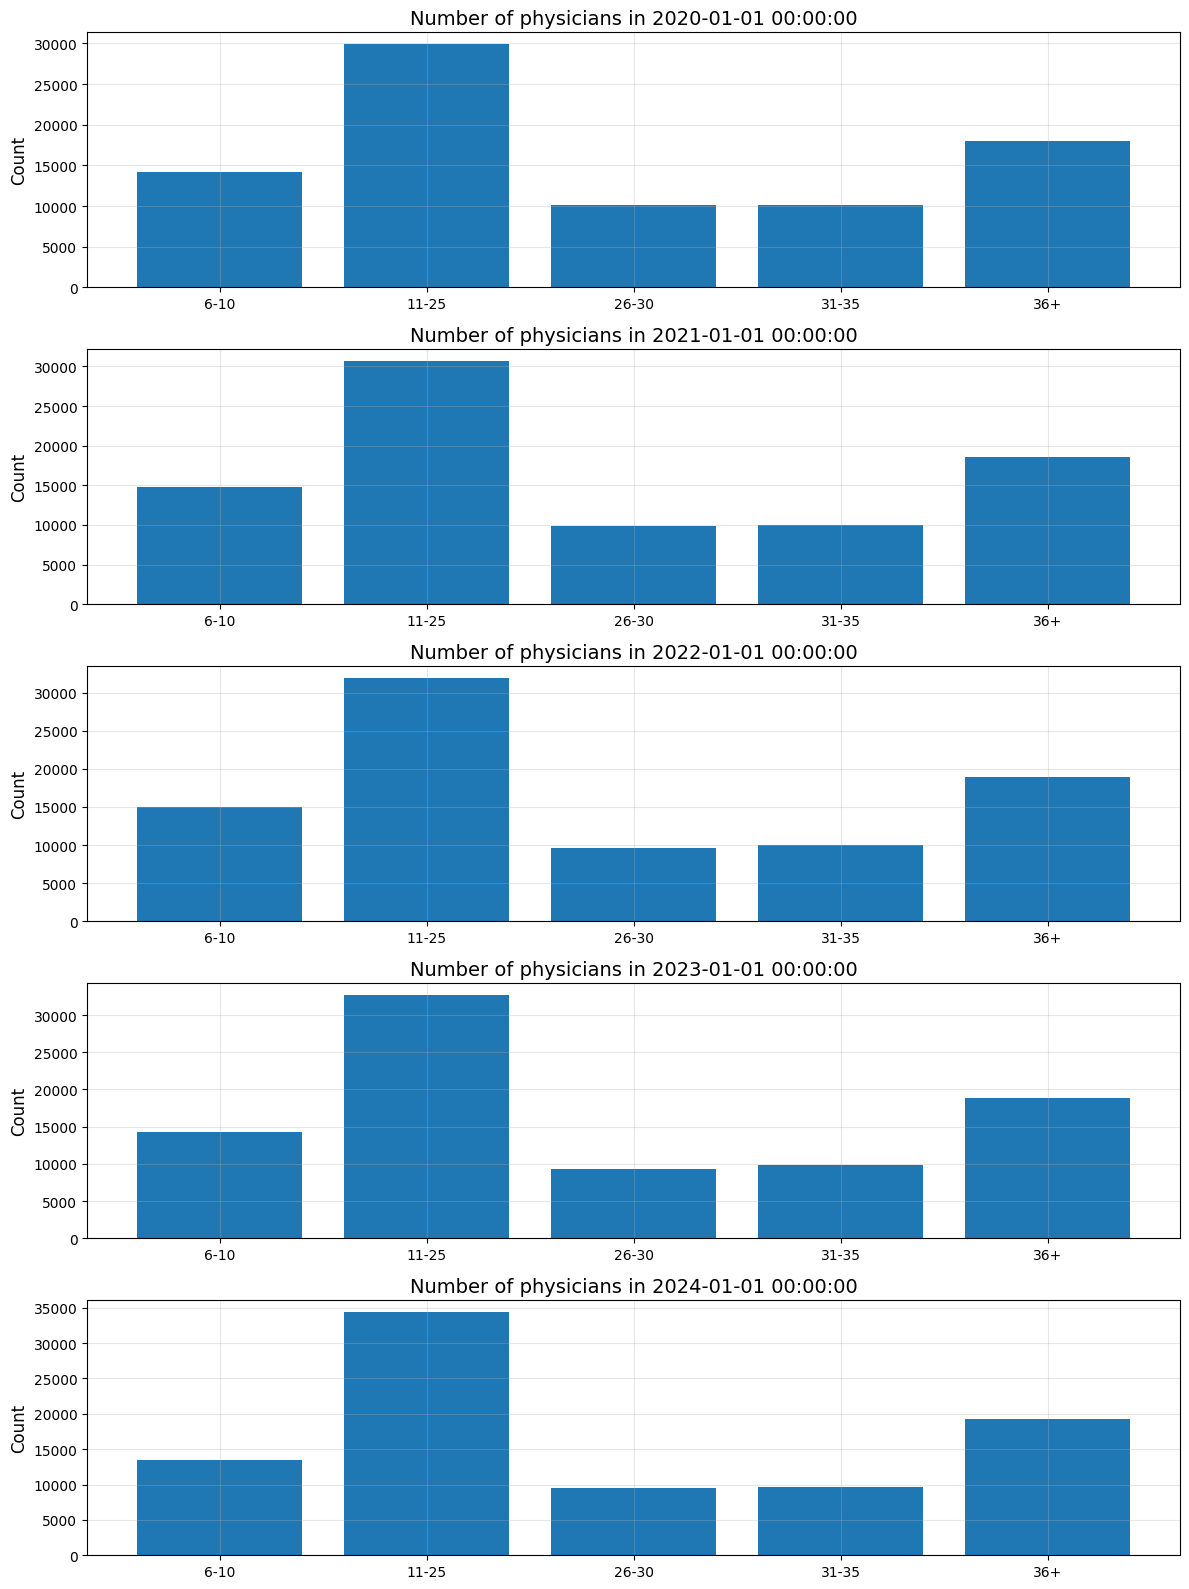

In [72]:
# display data for each graduation
import matplotlib.pyplot as plt

fix, axes = plt.subplots(5, 1, figsize=(12,16))

for idx, year in enumerate(yearly_data_graduation['Year']):
    # filter the data for each year before plotting
    year_data = yearly_data_graduation[yearly_data_graduation['Year'] == year]
    # accessing each plot by idx
    axes[idx].bar(['6-10', '11-25', '26-30', '31-35', '36+'],
                  [year_data['Years since graduation: 6–10'].values[0],
                  year_data['Years since graduation: 11–25'].values[0],
                   year_data['Years since graduation: 26–30'].values[0],
                   year_data['Years since graduation: 31–35'].values[0],
                   year_data['Years since graduation: 36 and more'].values[0]]
                  )
    axes[idx].set_title(f'Number of physicians in {year}', fontsize=14)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We have a dominated group of family doctors throghout the years, who graduated in the last 11-25 yeras. 

In [10]:
# Display data coverage

# We noticed that a year column is int64

In [11]:
year_column = 'Year'

unique_year_ph = sorted(df_physicians[year_column].unique())

print(f'The CIHI Physician data covers: {unique_year_ph[0]}-{unique_year_ph[-1]}.\n')

print(f'Start year: {unique_year_ph[0]}')
print(f'End year: {unique_year_ph[-1]}\n')

print(f'Total years: {len(unique_year_ph)} years of data.')

The CIHI Physician data covers: 2020-2024.

Start year: 2020
End year: 2024

Total years: 5 years of data.


In [12]:
# Check data sizes

print('CIHI physician data shape:',df_physicians.shape)
print('Number of rows:', len(df_physicians))
print('Number of columns:', len(df_physicians.columns))

CIHI physician data shape: (490, 25)
Number of rows: 490
Number of columns: 25


In [13]:
# Display Summary

print("=" * 50)
print('DATA SUMMARY')
print("=" * 50)

print("\n📊 Statistics Canada (Patient Satisfaction)")
print(f"   Records: {len(df_satisfaction)}")
print(f"   Columns: {len(df_satisfaction.columns)}")
print(f"   Year range: {unique_years_stat[0]}-{unique_years_stat[-1]}")

print("\n🏥 CIHI (Physician Supply)")
print(f"   Records: {len(df_physicians)}")
print(f"   Columns: {len(df_physicians.columns)}")
print(f"   Year range: {unique_year_ph[0]}-{unique_year_ph[-1]}")

DATA SUMMARY

📊 Statistics Canada (Patient Satisfaction)
   Records: 5940
   Columns: 17
   Year range: 2000-2007

🏥 CIHI (Physician Supply)
   Records: 490
   Columns: 25
   Year range: 2020-2024


In [14]:
df_physicians['Year'] = pd.to_datetime(df_physicians['Year'], format='%Y')

In [15]:
df_physicians['Year']

0     2020-01-01
1     2020-01-01
2     2020-01-01
3     2020-01-01
4     2020-01-01
         ...    
485   2024-01-01
486   2024-01-01
487   2024-01-01
488   2024-01-01
489   2024-01-01
Name: Year, Length: 490, dtype: datetime64[ns]

In [16]:
df_physicians.dtypes

Year                                             datetime64[ns]
Jurisdiction                                             object
Specialty                                                object
Number of physicians                                      int64
Physician to population ratio                           float64
Number male                                               int64
Number female                                             int64
Number sex unknown                                        int64
Average age                                             float64
Number in Rural areas                                     int64
Number in Urban areas                                     int64
Place of MD Graduation: Canada                            int64
Place of MD Graduation: Foreign                           int64
Years since graduation: Fewer than 6                      int64
Years since graduation: 6–10                              int64
Years since graduation: 11–25           

In [17]:
unique_years = df_physicians['Year'].dt.year.unique()
print(f'The data starts from {unique_years[0]}-{unique_years[-1]}')

The data starts from 2020-2024


In [18]:
print("=" * 50)
print('Prepare data for linear regression analysis')
print("=" * 50)
df_physicians['Physicians_per_100k'] = (df_physicians['Number of physicians'] / 
                                        df_physicians['Statistics Canada Population']) * 100

# Family Physicians per 100k (only Family Medicine rows)
df_physicians['Family_Physicians_per_100k'] = 0  # Initialize

family_mask = df_physicians['Specialty'] == 'Family Medicine'
df_physicians.loc[family_mask, 'Family_Physicians_per_100k'] = (
    df_physicians.loc[family_mask, 'Number of physicians'] / 
    df_physicians.loc[family_mask, 'Statistics Canada Population']
) * 100

# Rural Percentage
df_physicians['Rural_Percentage'] = (df_physicians['Number in Rural areas'] / 
                                     df_physicians['Number of physicians']) * 100


Prepare data for linear regression analysis


/var/folders/wy/v92nv28111j7vk4ynsyxm2700000gn/T/ipykernel_2657/3752544625.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.12981985 0.10992946 0.13799476 0.13683383 0.12978455 0.11509428
 0.10825052 0.12052569 0.12469668 0.13299586 0.16921684 0.08987956
 0.05319284 0.12305726 0.13186455 0.11472063 0.13741264 0.13947866
 0.13222088 0.11601828 0.10812372 0.11646717 0.12237306 0.13618627
 0.16526617 0.09421476 0.04490346 0.12408255 0.13212675 0.11661773
 0.13128339 0.13889163 0.13200458 0.11502197 0.11114509 0.11930876
 0.12009097 0.14042034 0.16856492 0.10082    0.061794   0.12402939
 0.12358348 0.11801074 0.12106171 0.14191471 0.13052638 0.10995182
 0.10737292 0.11833223 0.11638347 0.13766478 0.16496932 0.10295204
 0.06142506 0.1204087  0.12141286 0.11817418 0.12347009 0.13799884
 0.12920653 0.10731751 0.11175794 0.11525448 0.11729034 0.13754666
 0.15416238 0.08718786 0.04859205 0.11913216]' has d

In [19]:
# Create a new column for retention rate

df_physicians['Physician_Retention_Rate'] = (1 - (
    (df_physicians['Number of physicians who moved abroad'] + df_physicians['Loss_count']) / 
    df_physicians['Number of physicians']
    )) * 100

print('\n' + '=' * 50)
print('Retention Rate')
print('=' * 50)
# print(df_physicians[['Year', 'Jurisdiction', 
#                      'Number of physicians',

#                      'Number of physicians who moved abroad', 
#                      'Loss_count','Physician_Retention_Rate']].head(15))


print(df_physicians[['Year', 'Specialty','Physician_Retention_Rate']]) 


Retention Rate
          Year               Specialty  Physician_Retention_Rate
0   2020-01-01        Physician Supply                 98.236591
1   2020-01-01         Family Medicine                 97.953216
2   2020-01-01             Specialists                 98.522895
3   2020-01-01    Clinical Specialists                100.000000
4   2020-01-01  Laboratory Specialists                100.000000
..         ...                     ...                       ...
485 2024-01-01             Specialists                 99.863006
486 2024-01-01    Clinical Specialists                100.000000
487 2024-01-01  Laboratory Specialists                100.000000
488 2024-01-01    Surgical Specialists                100.000000
489 2024-01-01      Medical Scientists                100.000000

[490 rows x 3 columns]


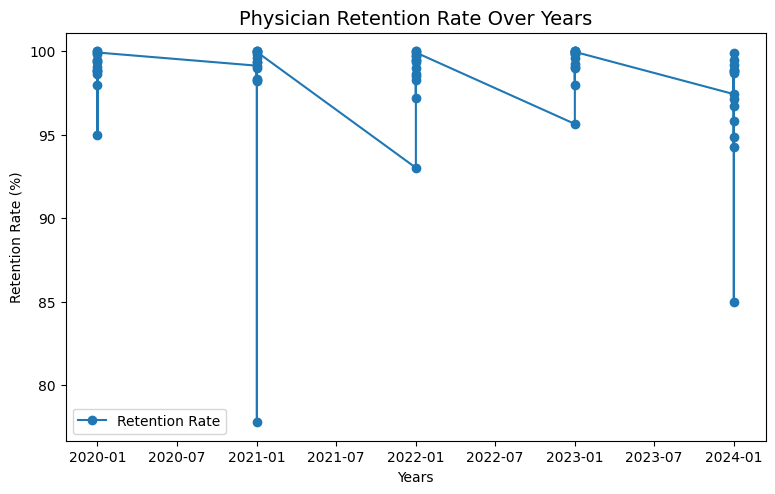

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_physicians is already defined
# Filter for Family doctors only
data = df_physicians[df_physicians['Specialty'] == 'Family Medicine']

# Prepare the DataFrame for the table
df_data = data[['Year','Physician_Retention_Rate']]
df_data.set_index('Year', inplace=True)

# Create a figure and axis for the plot
plt.figure(figsize=(10, 6))

# Create the line plot
plt.plot(df_data.index, df_data['Physician_Retention_Rate'], label='Retention Rate', marker='o')
plt.xlabel('Years')
plt.ylabel('Retention Rate (%)')
plt.title('Physician Retention Rate Over Years', fontsize=14)

plt.subplots_adjust(left=0.2, bottom=0.2)

plt.legend()
plt.show()


In [21]:
print('\n' + '=' * 50)
print('Prepare data for ML model')
print('=' * 50)

# Aggregate by province and year
df_model_ph = df_physicians.groupby(['Year', 'Jurisdiction']).agg({
    'Physicians_per_100k': 'mean',
    'Family_Physicians_per_100k': 'sum',
    'Rural_Percentage': 'mean',
    'Physician_Retention_Rate': 'mean',
    'Average age': 'mean',
    'Statistics Canada Population': 'first'
}).reset_index()


print(f'Aggregated data: {df_model_ph.shape[0]}')
print(df_model_ph.head(5))


Prepare data for ML model
Aggregated data: 70
        Year Jurisdiction  Physicians_per_100k  Family_Physicians_per_100k  \
0 2020-01-01        Alta.                  inf                    0.124697   
1 2020-01-01         B.C.                  inf                    0.132996   
2 2020-01-01       Canada                  inf                    0.123057   
3 2020-01-01         Man.                  inf                    0.108251   
4 2020-01-01         N.B.                  inf                    0.136834   

   Rural_Percentage  Physician_Retention_Rate  Average age  \
0          2.977412                 99.327321    20.454965   
1          2.205052                 99.725640    20.949139   
2          3.083031                 99.952883    21.084910   
3          5.489562                 99.430845    20.861691   
4          7.505353                 99.524741    21.549752   

   Statistics Canada Population  
0                       4407495  
1                       5176101  
2        

In [22]:
print('\n' + '=' * 50)
print('Create target variable')
print('=' * 50)

df_model_ph['No_Primary_Care_Percent'] = 100 - df_model_ph['Physician_Retention_Rate']

print('Target variable created.')


Create target variable
Target variable created.


In [23]:
print('\n' + '=' * 50)
print('Select features for linear regression')
print('=' * 50)

features = ['Family_Physicians_per_100k', 'Rural_Percentage', 'Physician_Retention_Rate']

target = 'No_Primary_Care_Percent'

# remove rows with missing values
df_model_clean = df_model_ph.dropna(subset=features + [target]).copy()

# remove rows with infinity values
df_model_clean = df_model_clean[~np.isinf(df_model_clean[features + [target]]).any(axis=1)]

# prepare X and y
X = df_model_clean[features].values
y = df_model_clean[target].values

print(f'Features (X): {features}')
print(f'Target (y): {target}')
print(f'Number of records: {len(X)}')


Select features for linear regression
Features (X): ['Family_Physicians_per_100k', 'Rural_Percentage', 'Physician_Retention_Rate']
Target (y): No_Primary_Care_Percent
Number of records: 70


In [24]:
df_model_clean['Jurisdiction'].unique().tolist()


['Alta.',
 'B.C.',
 'Canada',
 'Man.',
 'N.B.',
 'N.L.',
 'N.S.',
 'N.W.T.',
 'Nun.',
 'Ont.',
 'P.E.I.',
 'Que.',
 'Sask.',
 'Y.T.']

In [25]:
# to replace the above abbreviations with full names of provinces/ territories

province_mapping = {
    'Alta.': 'Alberta',
    'B.C.': 'British Columbia',
    'Man.': 'Manitoba',
    'N.B.': 'New Brunswick',
    'N.L.': 'Newfoundland and Labrador',
    'N.S.': 'Nova Scotia',
    'N.W.T.': 'Northwest Territories',
    'Nun.': 'Nunavut',
    'Ont.': 'Ontario',
    'P.E.I.': 'Prince Edward Island',
    'Que.': 'Quebec',
    'Sask.': 'Saskatchewan',
    'Y.T.': 'Yukon',
    'Canada': 'Canada'
}

df_model_clean['Jurisdiction'] = df_model_clean['Jurisdiction'].map(province_mapping)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [27]:
print('\n' + '=' * 50)
print('Standardize features')
print('=' * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features standardized (scaled)')



Standardize features
Features standardized (scaled)


In [28]:
print("\n" + "=" * 60)
print("Train Linear Regression Model")
print("=" * 60)

model = LinearRegression()
model.fit(X_scaled, y)

# predictions
y_pred = model.predict(X_scaled)

# model evaluation

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print('Model performance:'+ '\n')
print(f'R2 score: {r2:.4f}')
print(f'RMSE: {rmse:.5f}%')


Train Linear Regression Model
Model performance:

R2 score: 1.0000
RMSE: 0.00000%


In [29]:
print("\n" + "=" * 60)
print("REGRESSION COEFFICIENTS (Standardized)")
print("=" * 60)
print(f"Physicians_per_100k: {model.coef_[0]:.4f}")
print(f"Rural_Percentage: {model.coef_[1]:.4f}")
print(f"Retention_Rate_Percent: {model.coef_[2]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


REGRESSION COEFFICIENTS (Standardized)
Physicians_per_100k: -0.0000
Rural_Percentage: 0.0000
Retention_Rate_Percent: -1.4107
Intercept: 0.9002


In [30]:
print("\n" + "=" * 60)
print("PREDICTIONS BY PROVINCE AND YEAR")
print("=" * 60)

df_model_clean['Predicted_No_Primary_Care'] = y_pred
df_model_clean['Error'] = abs(df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care'])

# Show predictions
for idx, row in df_model_clean.iterrows():
    print(f"\n{row['Jurisdiction']} ({str(row['Year'])}):")
    print(f"  Physicians per 100k: {row['Physicians_per_100k']:.1f}")
    print(f"  Retention Rate: {row['Physician_Retention_Rate']:.1f}%")
    print(f"  Actual % without primary care: {row[target]:.1f}%")
    print(f"  Predicted % without primary care: {row['Predicted_No_Primary_Care']:.1f}%")
    print(f"  Error: {row['Error']:.1f}%")




PREDICTIONS BY PROVINCE AND YEAR

Alberta (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.3%
  Actual % without primary care: 0.7%
  Predicted % without primary care: 0.7%
  Error: 0.0%

British Columbia (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.7%
  Actual % without primary care: 0.3%
  Predicted % without primary care: 0.3%
  Error: 0.0%

Canada (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 100.0%
  Actual % without primary care: 0.0%
  Predicted % without primary care: 0.0%
  Error: 0.0%

Manitoba (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.4%
  Actual % without primary care: 0.6%
  Predicted % without primary care: 0.6%
  Error: 0.0%

New Brunswick (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.5%
  Actual % without primary care: 0.5%
  Predicted % without primary care: 0.5%
  Error: 0.0%

Newfoundland and Labrador (2020-01-01 00:00:00):
  Physicians per 100


✓ Visualization saved as 'canada_primary_care_analysis.png'


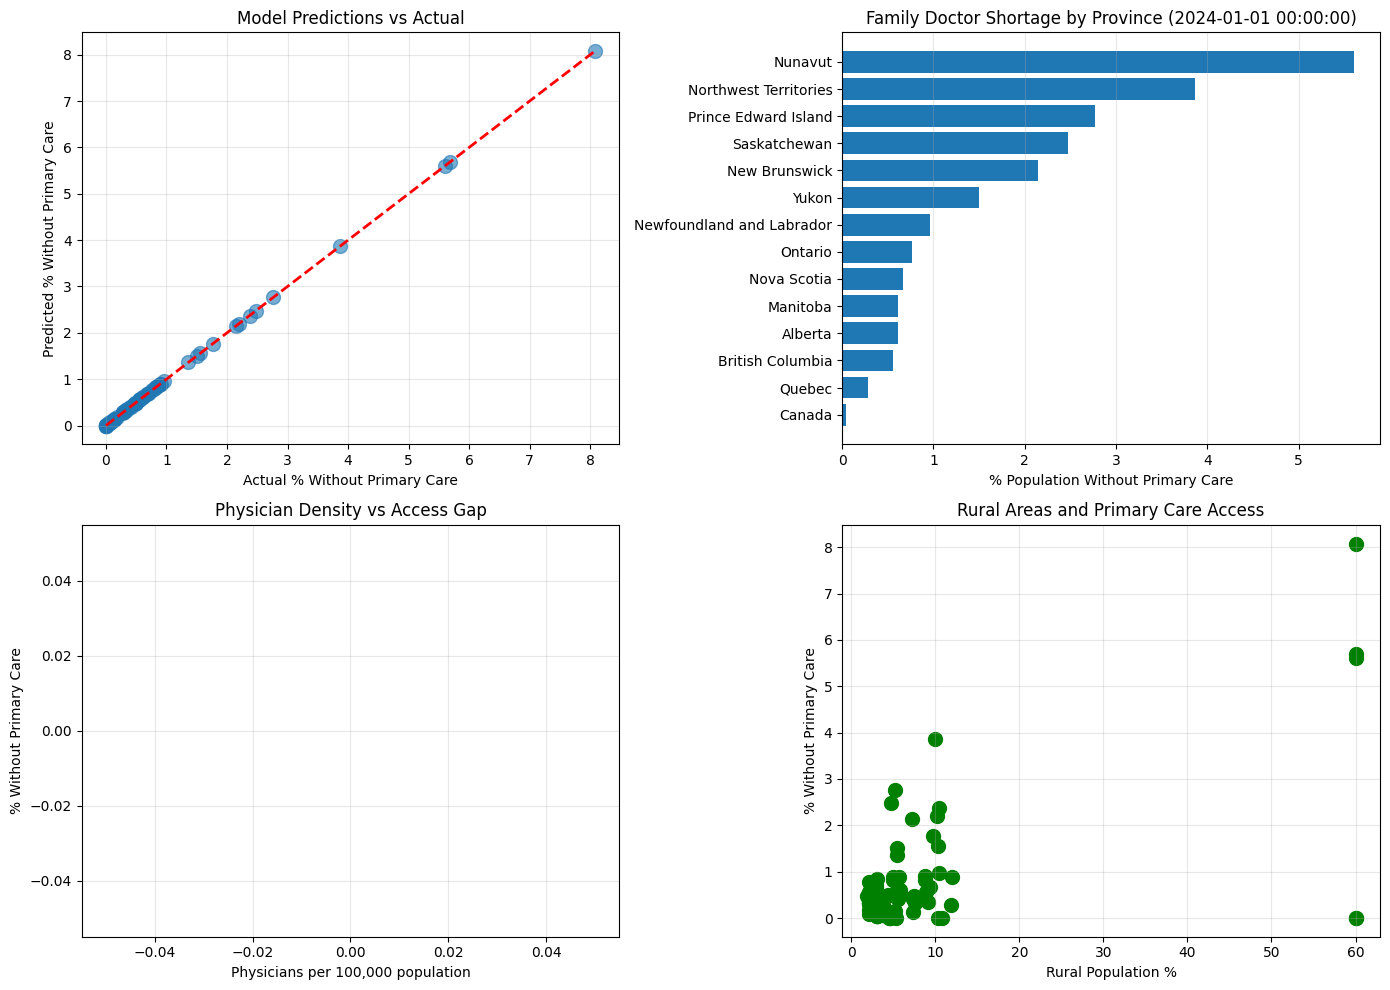

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(df_model_clean[target], df_model_clean['Predicted_No_Primary_Care'], alpha=0.6, s=100)
axes[0, 0].plot([df_model_clean[target].min(), df_model_clean[target].max()], 
                [df_model_clean[target].min(), df_model_clean[target].max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual % Without Primary Care')
axes[0, 0].set_ylabel('Predicted % Without Primary Care')
axes[0, 0].set_title('Model Predictions vs Actual')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Shortage by Province (latest year)
latest_year = df_model_clean['Year'].max()
df_latest = df_model_clean[df_model_clean['Year'] == latest_year].sort_values(target, ascending=True)
axes[0, 1].barh(df_latest['Jurisdiction'], df_latest[target])
axes[0, 1].set_xlabel('% Population Without Primary Care')
axes[0, 1].set_title(f'Family Doctor Shortage by Province ({str(latest_year)})')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Physicians per 100k vs Shortage
axes[1, 0].scatter(df_model_clean['Physicians_per_100k'], df_model_clean[target], s=100)
axes[1, 0].set_xlabel('Physicians per 100,000 population')
axes[1, 0].set_ylabel('% Without Primary Care')
axes[1, 0].set_title('Physician Density vs Access Gap')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Rural % vs Shortage
axes[1, 1].scatter(df_model_clean['Rural_Percentage'], df_model_clean[target], s=100, color='green')
axes[1, 1].set_xlabel('Rural Population %')
axes[1, 1].set_ylabel('% Without Primary Care')
axes[1, 1].set_title('Rural Areas and Primary Care Access')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('canada_primary_care_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'canada_primary_care_analysis.png'")
plt.show()


1. The model predicts positively. Points are very closed to the line.
2. In terms of doctor shortage by province, Nunavut, Northwest Territories and Prince Edward island have the worst shortage.
3. The plot is empty. This feature does not explain the shortage. 
4. As in the previous graph, we saw that Nunavat was on the first place. It seems like it has 60% rural population and 6-8% without primary care. The rest on the left side, 0-20% rural, have a good access to primary care. 

In [32]:
print("\nProvinces with lowest access (highest shortage):")
worst = df_model_clean.nlargest(3, target)[['Jurisdiction', 'Year', target]]
print(worst.to_string(index=False))

print("\nProvinces with best access (lowest shortage):")
best = df_model_clean.nsmallest(3, target)[['Jurisdiction', 'Year', target]]
print(best.to_string(index=False))


Provinces with lowest access (highest shortage):
Jurisdiction       Year  No_Primary_Care_Percent
     Nunavut 2021-01-01                 8.080808
     Nunavut 2022-01-01                 5.689655
     Nunavut 2024-01-01                 5.608696

Provinces with best access (lowest shortage):
        Jurisdiction       Year  No_Primary_Care_Percent
             Nunavut 2020-01-01                      0.0
               Yukon 2020-01-01                      0.0
Prince Edward Island 2021-01-01                      0.0


In [33]:
! pip install xgboost

In [34]:
# XGboost model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor

# X_train, Y_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
# fit model
model_xgboost = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)


model_xgboost.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
# evaluate model

y_pred = model_xgboost.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_squared_error(y, y_pred)

print('='* 50)
print('Model performace')
print('=' * 50)

print(f'R2 score: {r2:.4f}')
print(f'Prediction error, RMSE: {rmse:.4f}%')
print(f' On average, predictions are off by {rmse:.4f} percentage points')
print(f'MAE: {mae:.5f}%')
               

Model performace
R2 score: 1.0000
Prediction error, RMSE: 0.0055%
 On average, predictions are off by 0.0055 percentage points
MAE: 0.00003%


In [37]:
print("\n" + "=" * 60)
print("PREDICTIONS BY PROVINCE AND YEAR")
print("=" * 60)

target = 'No_Primary_Care_Percent'

df_model_clean['Predicted_No_Primary_Care'] = y_pred
df_model_clean['Error'] = abs(df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care'])
df_model_clean['Error_Percent'] = (df_model_clean['Error']/ df_model_clean[target] * 100).round(2)

print('Sample predictions: ')
# Show predictions
for idx, row in df_model_clean.iterrows():
    print(f"\n{row['Jurisdiction']} ({str(row['Year'])}):")
    print(f"  Physicians per 100k: {row['Physicians_per_100k']:.1f}")
    print(f"  Retention Rate: {row['Physician_Retention_Rate']:.1f}%")
    print(f"  Actual % without primary care: {row[target]:.1f}%")
    print(f"  Predicted % without primary care: {row['Predicted_No_Primary_Care']:.1f}%")
    print(f"  Error: {row['Error']:.1f}%")




PREDICTIONS BY PROVINCE AND YEAR
Sample predictions: 

Alberta (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.3%
  Actual % without primary care: 0.7%
  Predicted % without primary care: 0.7%
  Error: 0.0%

British Columbia (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.7%
  Actual % without primary care: 0.3%
  Predicted % without primary care: 0.3%
  Error: 0.0%

Canada (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 100.0%
  Actual % without primary care: 0.0%
  Predicted % without primary care: 0.0%
  Error: 0.0%

Manitoba (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.4%
  Actual % without primary care: 0.6%
  Predicted % without primary care: 0.6%
  Error: 0.0%

New Brunswick (2020-01-01 00:00:00):
  Physicians per 100k: inf
  Retention Rate: 99.5%
  Actual % without primary care: 0.5%
  Predicted % without primary care: 0.5%
  Error: 0.0%

Newfoundland and Labrador (2020-01-01 00:00:00):

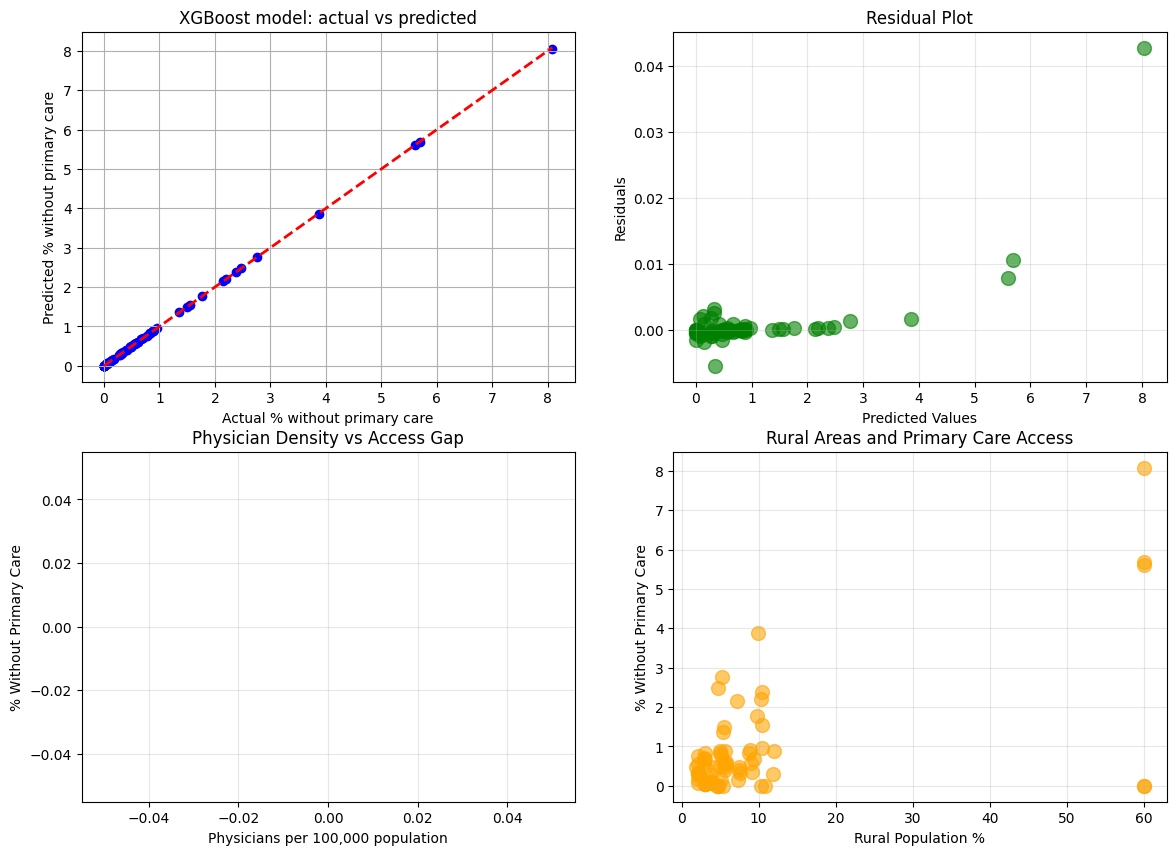

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# visualize actual vs predicted
axes[0, 0].scatter(df_model_clean[target], df_model_clean['Predicted_No_Primary_Care'], color='blue')
axes[0, 0].plot([df_model_clean[target].min(), df_model_clean[target].max()], 
                [df_model_clean[target].min(), df_model_clean[target].max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual % without primary care')
axes[0, 0].set_ylabel('Predicted % without primary care')
axes[0, 0].set_title(f'XGBoost model: actual vs predicted')
axes[0, 0].grid(True)

# to show errors
residuals = df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care']
axes[0, 1].scatter(df_model_clean['Predicted_No_Primary_Care'], residuals, alpha=0.6, s=100, color='green')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# to show physicians per 100k vs shortage
axes[1, 0].scatter(df_model_clean['Physicians_per_100k'], df_model_clean[target], 
                   alpha=0.6, s=100, color='purple')
axes[1, 0].set_xlabel('Physicians per 100,000 population')
axes[1, 0].set_ylabel('% Without Primary Care')
axes[1, 0].set_title('Physician Density vs Access Gap')
axes[1, 0].grid(True, alpha=0.3)

#  Rural % vs Shortage
axes[1, 1].scatter(df_model_clean['Rural_Percentage'], df_model_clean[target], 
                   alpha=0.6, s=100, color='orange')
axes[1, 1].set_xlabel('Rural Population %')
axes[1, 1].set_ylabel('% Without Primary Care')
axes[1, 1].set_title('Rural Areas and Primary Care Access')
axes[1, 1].grid(True, alpha=0.3)

1. The model works well. 
2. It shows how far off the predictions are. Mostly, all points are scattered around 0, which is good. We have a few of points off, but not too many. It seems like errors are random.
3. 

In [39]:
print("\n✓ Provinces with WORST primary care access:")
worst = df_model_clean.nlargest(3, target)[['Jurisdiction', 'Year', target]]
for idx, row in worst.iterrows():
    print(f"  {row['Jurisdiction']} ({str(row['Year'])}): {row[target]:.4f}% without primary care")

print("\n✓ Provinces with BEST primary care access:")
best = df_model_clean.nsmallest(3, target)[['Jurisdiction', 'Year', target]]
for idx, row in best.iterrows():
    print(f"  {row['Jurisdiction']} ({str(row['Year'])}): {row[target]:.9f}% without primary care")



✓ Provinces with WORST primary care access:
  Nunavut (2021-01-01 00:00:00): 8.0808% without primary care
  Nunavut (2022-01-01 00:00:00): 5.6897% without primary care
  Nunavut (2024-01-01 00:00:00): 5.6087% without primary care

✓ Provinces with BEST primary care access:
  Nunavut (2020-01-01 00:00:00): 0.000000000% without primary care
  Yukon (2020-01-01 00:00:00): 0.000000000% without primary care
  Prince Edward Island (2021-01-01 00:00:00): 0.000000000% without primary care


In [40]:
# CELL: Check the ranges of your features
print("=" * 50)
print("DATA RANGES:")
print("=" * 50)

print("\nPhysicians_per_100k:")
print(f"  Min: {df_model_clean['Physicians_per_100k'].min():.2f}")
print(f"  Max: {df_model_clean['Physicians_per_100k'].max():.2f}")
print(f"  Mean: {df_model_clean['Physicians_per_100k'].mean():.2f}")

print("\nRural_Percentage:")
print(f"  Min: {df_model_clean['Rural_Percentage'].min():.2f}")
print(f"  Max: {df_model_clean['Rural_Percentage'].max():.2f}")
print(f"  Mean: {df_model_clean['Rural_Percentage'].mean():.2f}")

print("\nRetention_Rate_Percent:")
print(f"  Min: {df_model_clean['Physician_Retention_Rate'].min():.2f}")
print(f"  Max: {df_model_clean['Physician_Retention_Rate'].max():.2f}")
print(f"  Mean: {df_model_clean['Physician_Retention_Rate'].mean():.2f}")

print("\nNo_Primary_Care_Percent:")
print(f"  Min: {df_model_clean['No_Primary_Care_Percent'].min():.2f}")
print(f"  Max: {df_model_clean['No_Primary_Care_Percent'].max():.2f}")
print(f"  Mean: {df_model_clean['No_Primary_Care_Percent'].mean():.2f}")

DATA RANGES:

Physicians_per_100k:
  Min: inf
  Max: inf
  Mean: inf

Rural_Percentage:
  Min: 1.83
  Max: 60.00
  Mean: 9.46

Retention_Rate_Percent:
  Min: 91.92
  Max: 100.00
  Mean: 99.10

No_Primary_Care_Percent:
  Min: 0.00
  Max: 8.08
  Mean: 0.90
